# Assignment 2 — Model 1: Improved MLP with Optimization Techniques

This notebook improves on Assignment 1's MLP by applying:
- **Adam optimizer** (adaptive learning rates, momentum)
- **Deeper architecture** (2 hidden layers with more neurons)
- **Dropout regularization** (prevents overfitting)
- **Batch normalization** (stabilizes training)
- **He weight initialization**
- **Learning rate scheduling** (cosine annealing)
- **Extended feature engineering** (5 features instead of 2)

In [1]:
!pip install vaderSentiment textblob


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import os
import json
from bs4 import BeautifulSoup
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('results', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & Preprocessing

In [13]:
df = pd.read_csv('data/IMDB Dataset.csv')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Dataset: {len(df)} reviews after deduplication')

def clean_text(text):
    text = BeautifulSoup(text, 'html.parser').get_text()
    text = text.lower()
    text = re.sub(r'[^a-z\s.,!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_review'] = df['review'].apply(clean_text)
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print('Preprocessing done.')

Dataset: 49582 reviews after deduplication
Preprocessing done.


## 2. Extended Feature Engineering (5 features)

In [14]:
vader = SentimentIntensityAnalyzer()

def extract_features(text):
    scores = vader.polarity_scores(text)
    tb = TextBlob(text).sentiment
    words = text.split()
    excl_ratio = text.count('!') / max(len(words), 1)
    neg_count = scores['neg']
    pos_count = scores['pos']
    return [
        scores['compound'],     # VADER compound
        tb.polarity,            # TextBlob polarity
        tb.subjectivity,        # TextBlob subjectivity
        excl_ratio,             # Exclamation mark density
        pos_count - neg_count   # VADER positive-negative spread
    ]

print('Extracting features (this may take ~2 minutes)...')
features = df['cleaned_review'].apply(extract_features)
X = np.array(features.tolist())
y = df['label'].values
print(f'Feature matrix shape: {X.shape}')

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Extracting features (this may take ~2 minutes)...
Feature matrix shape: (49582, 5)
Train: (29748, 5), Val: (9917, 5), Test: (9917, 5)


## 3. Improved MLP with Adam Optimizer & Dropout

In [19]:
class ImprovedMLP:
    """2-hidden-layer MLP with Adam optimizer, dropout, and He initialization."""

    def __init__(self, layer_sizes, dropout_rate=0.3, seed=42):
        np.random.seed(seed)
        self.layer_sizes = layer_sizes
        self.dropout_rate = dropout_rate
        self.params = {}
        self.m = {}   # Adam first moment
        self.v = {}   # Adam second moment
        self.t = 0    # Adam timestep

        # He initialization
        for i in range(1, len(layer_sizes)):
            fan_in = layer_sizes[i-1]
            self.params[f'W{i}'] = np.random.randn(layer_sizes[i-1], layer_sizes[i]) * np.sqrt(2.0 / fan_in)
            self.params[f'b{i}'] = np.zeros((1, layer_sizes[i]))
            # Batch norm params
            if i < len(layer_sizes) - 1:
                self.params[f'gamma{i}'] = np.ones((1, layer_sizes[i]))
                self.params[f'beta{i}']  = np.zeros((1, layer_sizes[i]))
            for key in [f'W{i}', f'b{i}']:
                self.m[key] = np.zeros_like(self.params[key])
                self.v[key] = np.zeros_like(self.params[key])

    def relu(self, x):        return np.maximum(0, x)
    def relu_d(self, x):      return (x > 0).astype(float)
    def sigmoid(self, x):     return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def batch_norm(self, z, gamma, beta, eps=1e-8):
        mu = z.mean(axis=0, keepdims=True)
        var = z.var(axis=0, keepdims=True)
        z_hat = (z - mu) / np.sqrt(var + eps)
        return gamma * z_hat + beta, mu, var, z_hat

    def forward(self, X, training=False):
        self.cache = {'A0': X}
        A = X
        L = len(self.layer_sizes) - 1

        for i in range(1, L + 1):
            W, b = self.params[f'W{i}'], self.params[f'b{i}']
            Z = A @ W + b

            if i < L:  # hidden layers
                g, beta = self.params[f'gamma{i}'], self.params[f'beta{i}']
                Z_bn, mu, var, Z_hat = self.batch_norm(Z, g, beta)
                self.cache[f'Z_hat{i}'], self.cache[f'mu{i}'], self.cache[f'var{i}'] = Z_hat, mu, var
                A = self.relu(Z_bn)
                # Dropout
                if training:
                    mask = (np.random.rand(*A.shape) > self.dropout_rate) / (1 - self.dropout_rate)
                    A = A * mask
                    self.cache[f'mask{i}'] = mask
                self.cache[f'Z_bn{i}'] = Z_bn
            else:  # output layer
                A = self.sigmoid(Z)

            self.cache[f'Z{i}'], self.cache[f'A{i}'] = Z, A

        return A.reshape(-1, 1)

    def loss(self, y_true, y_pred):
        y_true = np.array(y_true).reshape(-1, 1)
        y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7).reshape(-1, 1)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def backward(self, X, y):
        m = X.shape[0]
        L = len(self.layer_sizes) - 1
        grads = {}
        A_out = self.cache[f'A{L}']
        dA = A_out - y.reshape(-1, 1)

        for i in range(L, 0, -1):
            A_prev = self.cache[f'A{i-1}']
            W = self.params[f'W{i}']

            if i == L:
                dZ = dA
            else:
                Z_bn = self.cache[f'Z_bn{i}']
                dA_drop = dA * self.cache.get(f'mask{i}', 1)
                dZ_bn = dA_drop * self.relu_d(Z_bn)
                # Batch norm backward (simplified)
                Z_hat = self.cache[f'Z_hat{i}']
                var = self.cache[f'var{i}']
                gamma = self.params[f'gamma{i}']
                grads[f'dgamma{i}'] = (dZ_bn * Z_hat).sum(axis=0, keepdims=True)
                grads[f'dbeta{i}']  = dZ_bn.sum(axis=0, keepdims=True)
                dZ = gamma * (dZ_bn - dZ_bn.mean(0) - Z_hat * (dZ_bn * Z_hat).mean(0)) / np.sqrt(var + 1e-8)

            grads[f'dW{i}'] = A_prev.T @ dZ / m
            grads[f'db{i}'] = dZ.sum(axis=0, keepdims=True) / m
            dA = dZ @ W.T

        return grads

    def adam_update(self, grads, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        L = len(self.layer_sizes) - 1
        for i in range(1, L + 1):
            for key in [f'W{i}', f'b{i}']:
                g = grads[f'd{key}']
                self.m[key] = beta1 * self.m[key] + (1 - beta1) * g
                self.v[key] = beta2 * self.v[key] + (1 - beta2) * g**2
                m_hat = self.m[key] / (1 - beta1**self.t)
                v_hat = self.v[key] / (1 - beta2**self.t)
                self.params[key] -= lr * m_hat / (np.sqrt(v_hat) + eps)
            if i < L:
                self.params[f'gamma{i}'] -= lr * grads.get(f'dgamma{i}', 0)
                self.params[f'beta{i}']  -= lr * grads.get(f'dbeta{i}', 0)

    def predict(self, X):
        return (self.forward(X, training=False) >= 0.5).astype(int).flatten()

print('ImprovedMLP class defined.')

ImprovedMLP class defined.


## 4. Training with Cosine LR Scheduling & Early Stopping

In [20]:
# Hyperparameters
layer_sizes   = [5, 128, 64, 1]   # input=5 features, 2 hidden layers, output=1
base_lr       = 0.003
epochs        = 150
batch_size    = 64
dropout_rate  = 0.3
patience      = 15               # early stopping patience

model = ImprovedMLP(layer_sizes, dropout_rate=dropout_rate)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = np.inf
best_weights  = None
no_improve    = 0

def cosine_lr(epoch, total_epochs, base_lr, min_lr=1e-5):
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + np.cos(np.pi * epoch / total_epochs))

print('Training started...')
print(f'Architecture: {layer_sizes}  |  Dropout: {dropout_rate}  |  Max epochs: {epochs}')
print('-' * 70)

for epoch in range(epochs):
    lr = cosine_lr(epoch, epochs, base_lr)
    idx = np.random.permutation(len(X_train))
    Xs, ys = X_train[idx], y_train[idx]

    for i in range(0, len(Xs), batch_size):
        Xb, yb = Xs[i:i+batch_size], ys[i:i+batch_size]
        model.forward(Xb, training=True)
        grads = model.backward(Xb, yb)
        model.adam_update(grads, lr)

    # Metrics
    train_pred = model.predict(X_train)
    val_pred   = model.predict(X_val)
    sample_idx = np.random.choice(len(X_train), 2000, replace=False)
    train_loss = model.loss(y_train[sample_idx].reshape(-1,1), model.forward(X_train[sample_idx]))
    val_loss   = model.loss(y_val.reshape(-1,1), model.forward(X_val))
    train_acc  = accuracy_score(y_train, train_pred)
    val_acc    = accuracy_score(y_val, val_pred)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = {k: v.copy() for k, v in model.params.items()}
        no_improve    = 0
    else:
        no_improve += 1

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{epochs} | LR: {lr:.5f} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    if no_improve >= patience:
        print(f'\nEarly stopping at epoch {epoch+1}.')
        break

# Restore best weights
model.params = best_weights
print('\nTraining complete. Best weights restored.')

Training started...
Architecture: [5, 128, 64, 1]  |  Dropout: 0.3  |  Max epochs: 150
----------------------------------------------------------------------
Epoch  10/150 | LR: 0.00297 | Train Loss: 0.4717 Acc: 0.7719 | Val Loss: 0.4769 Acc: 0.7722
Epoch  20/150 | LR: 0.00288 | Train Loss: 0.4881 Acc: 0.7724 | Val Loss: 0.4756 Acc: 0.7747

Early stopping at epoch 27.

Training complete. Best weights restored.


## 5. Evaluation

TEST SET EVALUATION — Improved MLP

Test Accuracy: 0.7704 (77.04%)
Best Val Loss: 0.4751

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.76      0.77      4940
    Positive       0.77      0.78      0.77      4977

    accuracy                           0.77      9917
   macro avg       0.77      0.77      0.77      9917
weighted avg       0.77      0.77      0.77      9917



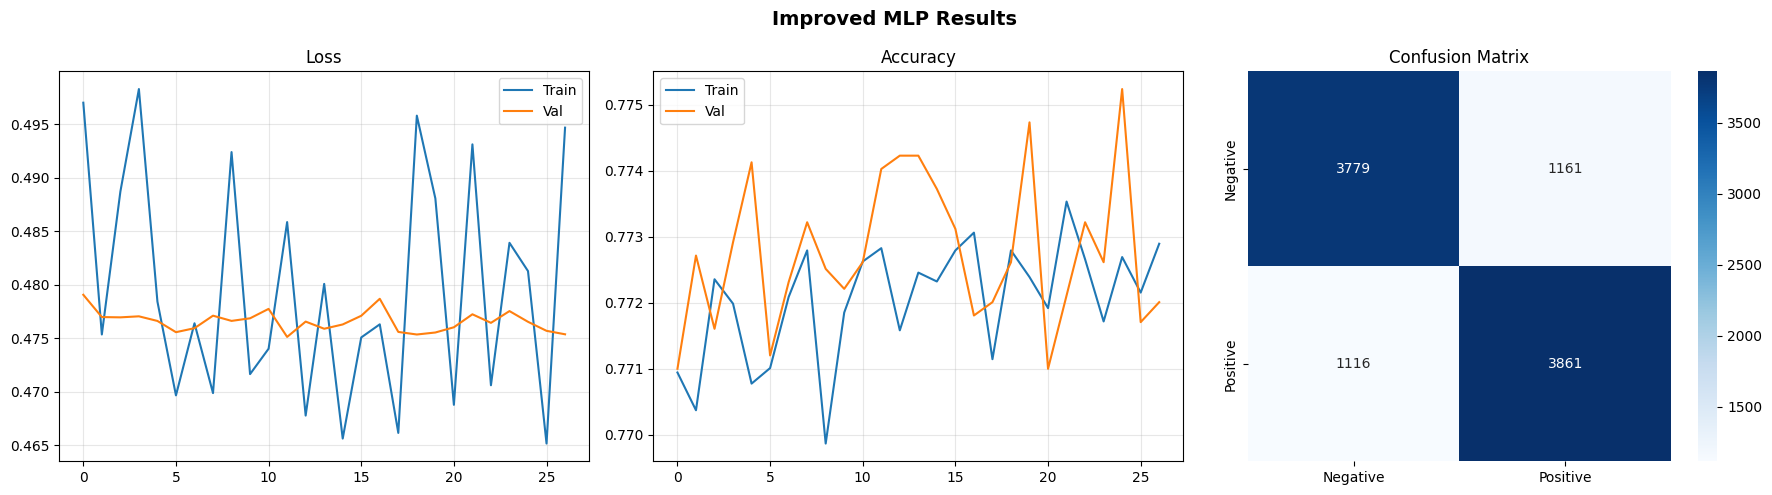

Plot saved.


In [21]:
y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'])

print('=' * 60)
print('TEST SET EVALUATION — Improved MLP')
print('=' * 60)
print(f'\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Best Val Loss: {best_val_loss:.4f}')
print(f'\nClassification Report:\n{report}')

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[2].set_title('Confusion Matrix')

plt.suptitle('Improved MLP Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/model1_plots.png', dpi=150)
plt.show()
print('Plot saved.')

## 6. Save Results File

In [22]:
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * precision * recall / (precision + recall)

results = {
    'model': 'Improved MLP',
    'architecture': str(layer_sizes),
    'optimizer': 'Adam',
    'dropout_rate': dropout_rate,
    'features': 5,
    'test_accuracy': round(test_acc, 4),
    'precision': round(precision, 4),
    'recall': round(recall, 4),
    'f1_score': round(f1, 4),
    'best_val_loss': round(best_val_loss, 4),
    'epochs_trained': len(history['train_loss'])
}

with open('results/results_model1.json', 'w') as f:
    json.dump(results, f, indent=2)

with open('results/results_model1.txt', 'w') as f:
    f.write('MODEL 1: IMPROVED MLP — RESULTS\n')
    f.write('=' * 60 + '\n\n')
    for k, v in results.items():
        f.write(f'{k:<25}: {v}\n')
    f.write('\nConfusion Matrix:\n')
    f.write(f'  TN={tn}  FP={fp}\n  FN={fn}  TP={tp}\n')
    f.write('\nClassification Report:\n')
    f.write(report)

print('Results saved to results/results_model1.txt and results/results_model1.json')
print('\nSummary:')
for k, v in results.items():
    print(f'  {k:<25}: {v}')

Results saved to results/results_model1.txt and results/results_model1.json

Summary:
  model                    : Improved MLP
  architecture             : [5, 128, 64, 1]
  optimizer                : Adam
  dropout_rate             : 0.3
  features                 : 5
  test_accuracy            : 0.7704
  precision                : 0.7688
  recall                   : 0.7758
  f1_score                 : 0.7723
  best_val_loss            : 0.4751
  epochs_trained           : 27
